In [739]:
import numpy as np 
import pandas as pd
import seaborn as sns 
import matplotlib.pyplot as plt 


### Cleaning Columns for the Salary prediction

### 1. Salary column


In [740]:
df = pd.read_csv('tech_job_market_2019_2026.csv')

In [741]:
df.head()

,job_id,company_name,company_type,sector,company_size_employees,hq_country,job_role,seniority_level,years_experience_min,years_experience_max,...,application_deadline,date_position_filled,position_status,number_of_applicants,number_of_interview_rounds,offers_extended,offers_accepted,salary_min_usd,salary_max_usd,layoff_within_12_months_flag
0,JOB041385,CobaltWealth,MNC,HealthTech,146085,Germany,SOC Analyst,Mid,3,5,...,2023-11-12 00:00:00,2023-11-20,Filled,98.0,4.0,5.0,5.0,-1,-1,N
1,JOB018462,DriftLearn,Mid-size,Cloud/Infra,5882,USA,Mobile Engineer (iOS),Mid,1,4,...,2025-06-29 00:00:00,NaN,Open,134.0,2.0,1.0,0.0,NaN,NaN,No
2,JOB110011,AnchorBuzz Labs,MNC,HealthTech,186507,USA,QA Engineer,Lead,7,15,...,2026-01-24 00:00:00,2026-02-08,Filled,36.0,4.0,1.0,1.0,238800.0,274700.0,0
3,JOB073462,KiteSphere,Unicorn,HealthTech,10930,Brazil,Research Scientist,Entry,1,4,...,2020-12-09 00:00:00,2020-12-21,Filled,300.0,1.0,6.0,5.0,96300.0,104000.0,Yes
4,JOB051683,AetherNode Co,MNC,Social/AdTech,42510,USA,Product Manager,Senior,6,9,...,2025-07-19 00:00:00,2025-09-15,Filled,43.0,3.0,1.0,1.0,"$186,800",245400.0,1


In [742]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 115000 entries, 0 to 114999
Data columns (total 28 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   job_id                        115000 non-null  object 
 1   company_name                  115000 non-null  object 
 2   company_type                  115000 non-null  object 
 3   sector                        115000 non-null  object 
 4   company_size_employees        115000 non-null  int64  
 5   hq_country                    115000 non-null  object 
 6   job_role                      115000 non-null  object 
 7   seniority_level               115000 non-null  object 
 8   years_experience_min          115000 non-null  int64  
 9   years_experience_max          115000 non-null  int64  
 10  required_tech_stack           115000 non-null  object 
 11  primary_programming_language  92525 non-null   object 
 12  work_mode                     115000 non-nul

In [743]:
df['salary_min_usd'].isnull().sum()

np.int64(3318)

In [744]:
df['salary_max_usd'].isnull().sum()

np.int64(3318)

In [745]:
df['salary_min_usd'] = df['salary_min_usd'].str.replace(r'[^0-9.-]',"",regex = True)

In [746]:
df['salary_min_usd'] = pd.to_numeric(df['salary_min_usd'], errors='coerce')


In [747]:
df['salary_min_usd'] = df['salary_min_usd'].fillna(df['salary_min_usd'].mean())

In [748]:
df['salary_min_usd'].astype(int)

0             -1
1         114677
2         238800
3          96300
4         186800
           ...  
114995    215300
114996     87500
114997    126000
114998    156000
114999    120400
Name: salary_min_usd, Length: 115000, dtype: int64

In [749]:
df['salary_max_usd'] = df['salary_max_usd'].str.replace(r'[^0-9.-]',"",regex = True)

In [750]:
df['salary_max_usd'] = pd.to_numeric(df['salary_max_usd'],errors='coerce')

In [751]:
df['salary_max_usd'] = df['salary_max_usd'].fillna(df['salary_max_usd'].mean())

In [752]:
df['salary_max_usd'].astype(int)

0             -1
1         141712
2         274700
3         104000
4         245400
           ...  
114995    254300
114996    113500
114997    156400
114998    174100
114999    147000
Name: salary_max_usd, Length: 115000, dtype: int64

In [753]:
df.loc[df['salary_min_usd'] <= 0, 'salary_min_usd'] = np.nan
df.loc[df['salary_max_usd'] <= 0, 'salary_max_usd'] = np.nan

In [754]:
df['Average_Salary'] = np.where(
    df['salary_min_usd'] > df['salary_max_usd'],
    None,
    (df['salary_max_usd'] + df['salary_min_usd']) / 2
)

In [755]:
df['Average_Salary']

0                   NaN
1         128194.873626
2              256750.0
3              100150.0
4              216100.0
              ...      
114995         234800.0
114996         100500.0
114997         141200.0
114998         165050.0
114999         133700.0
Name: Average_Salary, Length: 115000, dtype: object

In [756]:
df['Average_Salary'].isna().sum()

np.int64(1189)

In [757]:
df['Average_Salary'] = df['Average_Salary'].fillna(df['Average_Salary'].mean())


C:\Users\anshu\AppData\Local\Temp\ipykernel_6504\2889260269.py:1: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['Average_Salary'] = df['Average_Salary'].fillna(df['Average_Salary'].mean())


In [758]:
df['Average_Salary'].astype(int)

0         129035
1         128194
2         256750
3         100150
4         216100
           ...  
114995    234800
114996    100500
114997    141200
114998    165050
114999    133700
Name: Average_Salary, Length: 115000, dtype: int64

In [759]:
df['Average_experience'] = (df['years_experience_min']+df['years_experience_max'])/2

In [760]:
df['Average_experience']

0          4.0
1          2.5
2         11.0
3          2.5
4          7.5
          ... 
114995    11.5
114996     7.0
114997     4.0
114998     6.5
114999     4.5
Name: Average_experience, Length: 115000, dtype: float64

In [761]:
df['number_of_interview_rounds']

0         4.0
1         2.0
2         4.0
3         1.0
4         3.0
         ... 
114995    6.0
114996    4.0
114997    3.0
114998    4.0
114999    4.0
Name: number_of_interview_rounds, Length: 115000, dtype: float64

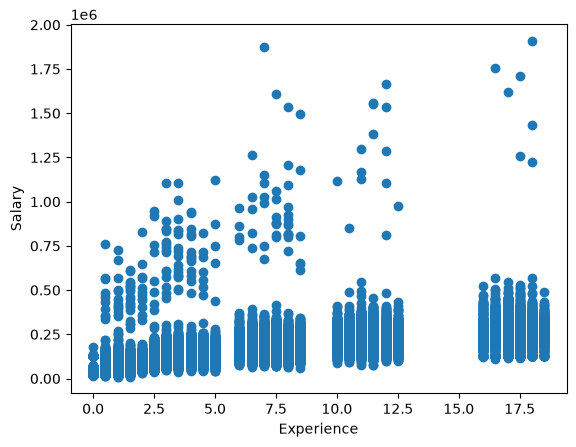

In [762]:
plt.scatter(y=df['Average_Salary'],x=df['Average_experience'])
plt.xlabel('Experience')
plt.ylabel('Salary')
plt.show()

### Using Categorical columns 
1. work_mode
2. job_role
3. job_location 
4. sectornum 
5. seniority_level

Cleaning work_mode

In [763]:
df['work_mode'].value_counts()

work_mode
Hybrid            48946
Remote            32320
Onsite            26731
HYBRID             1511
hybrid             1348
remote              598
Work From Home      567
WFH                 557
REMOTE              556
ONSITE              474
onsite              468
In-office           466
On-site             458
Name: count, dtype: int64

In [764]:
df['work_mode'].unique()

array(['Hybrid', 'Remote', 'Onsite', 'HYBRID', 'In-office', 'hybrid',
       'remote', 'WFH', 'onsite', 'REMOTE', 'ONSITE', 'On-site',
       'Work From Home'], dtype=object)

In [765]:
df['work_mode'] = df['work_mode'].str.strip().str.lower()

In [766]:
changed_work_mode = {
    'hybrid':'Hybrid',
    'remote':'Remote','wfh':'Remote','work from home':'Remote',
    'ONSITE':'Onsite','onsite':'Onsite','on-site':'Onsite','in-office':'Onsite','Onsite':'Onsite'
    }

In [767]:
df['work_mode'] = df['work_mode'].map(changed_work_mode)

In [768]:
df['work_mode'].value_counts()

work_mode
Hybrid    51805
Remote    34598
Onsite    28597
Name: count, dtype: int64

In [769]:
df['work_mode'].isna().sum()

np.int64(0)

In [770]:
df['job_location_country'].value_counts()

job_location_country
USA            36269
India          19639
UK             14620
Germany         7178
Canada          6319
Singapore       5781
Brazil          5360
France          4814
Australia       3585
Israel          3292
UAE             3059
Netherlands     2937
Ireland         2147
Name: count, dtype: int64

In [771]:
df['job_role'].isna().sum()
df['job_role'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 115000 entries, 0 to 114999
Series name: job_role
Non-Null Count   Dtype 
--------------   ----- 
115000 non-null  object
dtypes: object(1)
memory usage: 898.6+ KB


In [772]:
df['seniority_level'].value_counts()
df['seniority_level'].isna().sum()

np.int64(0)

Cleaning Sector

In [773]:
df['sector'].value_counts()

sector
E-commerce       16680
HealthTech       15273
Fintech          13134
EdTech           11523
Social/AdTech     9022
AI/ML             8900
SaaS              8620
Crypto/Web3       8038
Cloud/Infra       6567
Cybersecurity     5739
Logistics         5289
Gaming            5045
e-commerce         175
healthtech         147
fintech            141
edtech             126
social/adtech      100
crypto/web3         89
ai/ml               88
saas                88
cloud/infra         60
gaming              57
cybersecurity       50
logistics           49
Name: count, dtype: int64

In [774]:
df['sector'] = df['sector'].str.strip().str.lower()

In [775]:
cleaned_sector = {
    "e-commerce":"E-commerce",
    "healthtech":"HealthTech",
    "fintech":"Fintech",
    "edtech":"EdTech",
    "social/adtech":"Social/AdTech",
    "ai/ml":"AI/ML",
    "saas":"SaaS",
    "crypto/web3":"Crypto/Web3",
    "cloud/infra":"Cloud/Infra",
    "cybersecurity":"Cybersecurity",
    "logistics":"Logistics",
    "gaming":"Gaming"
}

In [776]:
df['sector'] = df['sector'].map(cleaned_sector)

In [777]:
df['sector'].value_counts()

sector
E-commerce       16855
HealthTech       15420
Fintech          13275
EdTech           11649
Social/AdTech     9122
AI/ML             8988
SaaS              8708
Crypto/Web3       8127
Cloud/Infra       6627
Cybersecurity     5789
Logistics         5338
Gaming            5102
Name: count, dtype: int64

In [778]:
df['sector'].isna().sum()

np.int64(0)

In [781]:
features = [
    'job_role',
    'seniority_level',
    'sector',
    'job_location_country',
    'work_mode',
    'Average_experience',
    'number_of_interview_rounds'
]

model_df = df[features + ['Average_Salary']].copy()
print(model_df.shape)
model_df.head()

(115000, 8)


,job_role,seniority_level,sector,job_location_country,work_mode,Average_experience,number_of_interview_rounds,Average_Salary
0,SOC Analyst,Mid,HealthTech,Germany,Hybrid,4.0,4.0,129035.264640
1,Mobile Engineer (iOS),Mid,Cloud/Infra,USA,Remote,2.5,2.0,128194.873626
2,QA Engineer,Lead,HealthTech,USA,Hybrid,11.0,4.0,256750.000000
3,Research Scientist,Entry,HealthTech,Germany,Onsite,2.5,1.0,100150.000000
4,Product Manager,Senior,Social/AdTech,India,Hybrid,7.5,3.0,216100.000000


In [783]:
model_df.isna().sum()

job_role                        0
seniority_level                 0
sector                          0
job_location_country            0
work_mode                       0
Average_experience              0
number_of_interview_rounds    436
Average_Salary                  0
dtype: int64

## Graph ploting for Visualization

### 1. To check salary distributioin

<Axes: ylabel='Average_Salary'>

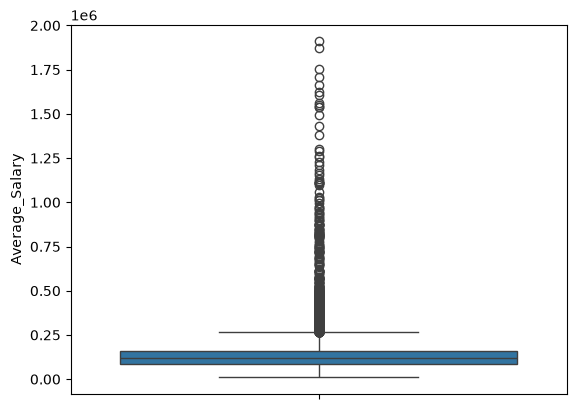

In [128]:
sns.boxplot(df['Average_Salary'])

**Insites** : There are a lot of outliers in the salary. 

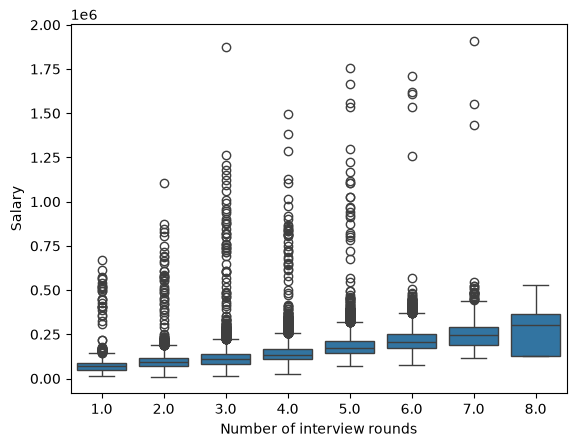

In [133]:
sns.boxplot(y= df['Average_Salary'],x= df['number_of_interview_rounds'])
plt.xlabel('Number of interview rounds')
plt.ylabel('Salary')
plt.show()

**Insites** : As the number of interview rounds are increasing, median salary is also increasing 

<Axes: xlabel='Average_Salary', ylabel='Count'>

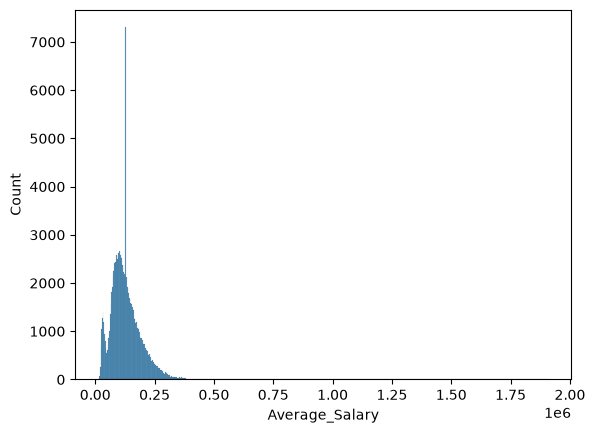

In [137]:
sns.histplot(df['Average_Salary'])